# Análisis de nodos del Sistema Eléctrico Nacional

In [2]:
#cargar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


### Carga de archivos

In [3]:

RUTA_DATOS = Path('data') / 'catalogo_nodosp_sen_v2026-09-23.xlsx'
df = pd.read_excel(RUTA_DATOS)

### Verificando posibles valores NaN


In [4]:
df.isna().sum()

SISTEMA                                0
CENTRO DE CONTROL REGIONAL             0
ZONA DE CARGA                          0
CLAVE                                  0
NOMBRE                                 0
NIVEL DE TENSIÓN (kV)                  0
DIRECTAMENTE MODELADA                  0
INDIRECTAMENTE MODELADA                0
DIRECTAMENTE MODELADA.1                0
INDIRECTAMENTE MODELADA.1              0
ZONA DE OPERACIÓN DE TRANSMISIÓN       0
GERENCIA REGIONAL DE TRANSMISIÓN       0
ZONA DE DISTRIBUCIÓN                   0
GERENCIA DIVISIONAL DE DISTRIBUCIÓN    0
CLAVE DE ENTIDAD FEDERATIVA (INEGI)    0
ENTIDAD FEDERATIVA (INEGI)             0
CLAVE DE MUNICIPIO (INEGI)             0
MUNICIPIO (INEGI)                      0
REGION DE TRANSMISION                  0
dtype: int64

No se encuentran valores NaN

In [5]:
#Para observar los datos provenientes del archivo base xlsx.
df.head()

,SISTEMA,CENTRO DE CONTROL REGIONAL,ZONA DE CARGA,CLAVE,NOMBRE,NIVEL DE TENSIÓN (kV),DIRECTAMENTE MODELADA,INDIRECTAMENTE MODELADA,DIRECTAMENTE MODELADA.1,INDIRECTAMENTE MODELADA.1,ZONA DE OPERACIÓN DE TRANSMISIÓN,GERENCIA REGIONAL DE TRANSMISIÓN,ZONA DE DISTRIBUCIÓN,GERENCIA DIVISIONAL DE DISTRIBUCIÓN,CLAVE DE ENTIDAD FEDERATIVA (INEGI),ENTIDAD FEDERATIVA (INEGI),CLAVE DE MUNICIPIO (INEGI),MUNICIPIO (INEGI),REGION DE TRANSMISION
0,BCA,BAJA CALIFORNIA,MEXICALI,07RIN-161,Rio Nuevo,161.0,No Aplica,Indirectamente Modelada,No Aplica,No Aplica,VALLE,BAJA CALIFORNIA,MEXICALI,BAJA CALIFORNIA,2,BAJA CALIFORNIA,2,MEXICALI,MEXICALI
1,BCA,BAJA CALIFORNIA,ENSENADA,07SAZ-115,Sauzal,115.0,No Aplica,Indirectamente Modelada,No Aplica,No Aplica,COSTA,BAJA CALIFORNIA,ENSENADA,BAJA CALIFORNIA,2,BAJA CALIFORNIA,1,ENSENADA,ENSENADA
2,BCA,BAJA CALIFORNIA,TIJUANA,07SHA-115,Sharp,115.0,No Aplica,Indirectamente Modelada,No Aplica,No Aplica,COSTA,BAJA CALIFORNIA,TIJUANA,BAJA CALIFORNIA,2,BAJA CALIFORNIA,4,TIJUANA,TIJUANA
3,BCA,BAJA CALIFORNIA,MEXICALI,07SIS-161,Santa Isabel,161.0,No Aplica,Indirectamente Modelada,No Aplica,No Aplica,VALLE,BAJA CALIFORNIA,MEXICALI,BAJA CALIFORNIA,2,BAJA CALIFORNIA,2,MEXICALI,MEXICALI
4,BCA,BAJA CALIFORNIA,ENSENADA,07SMN-115,San Simon,115.0,No Aplica,Indirectamente Modelada,No Aplica,No Aplica,COSTA,BAJA CALIFORNIA,ENSENADA,BAJA CALIFORNIA,2,BAJA CALIFORNIA,1,ENSENADA,ENSENADA


### Informacion y tipo de cada serie en DataFrame

In [6]:
print(len(df))
df.info()
print('La cantidad de filas y columnas en la base de datos es de:', df.shape)

2610
<class 'pandas.DataFrame'>
RangeIndex: 2610 entries, 0 to 2609
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   SISTEMA                              2610 non-null   str    
 1   CENTRO DE CONTROL REGIONAL           2610 non-null   str    
 2   ZONA DE CARGA                        2610 non-null   str    
 3   CLAVE                                2610 non-null   str    
 4   NOMBRE                               2610 non-null   str    
 5   NIVEL DE TENSIÓN (kV)                2610 non-null   float64
 6   DIRECTAMENTE MODELADA                2610 non-null   str    
 7   INDIRECTAMENTE MODELADA              2610 non-null   str    
 8   DIRECTAMENTE MODELADA.1              2610 non-null   str    
 9   INDIRECTAMENTE MODELADA.1            2610 non-null   str    
 10  ZONA DE OPERACIÓN DE TRANSMISIÓN     2610 non-null   str    
 11  GERENCIA REGIONAL DE TRANSMISIÓN    

Las columnas de **'CLAVE DE ENTIDAD FEDERATIVA (INEGI)'** y **'CLAVE DE MUNICIPIO (INEGI)'** hacen referencia al codigo de INEGI para 
estados y municipios respectivamente. 
Para los elementos de la serie 'CLAVE DE MUNICIPIO (INEGI)' puede repetirse debido a que esta clave es propia a cada estado, esta clave no corresponde a un unico municipio a nivel nacional, por lo que en la base de datos puede haber 2 municipios 1,2,3 etc. debido a que corresponde al conteo de municipios a nivel estatal.

In [7]:
#nombre de columnas para df
df.columns.tolist()

['SISTEMA',
 'CENTRO DE CONTROL REGIONAL',
 'ZONA DE CARGA',
 'CLAVE',
 'NOMBRE',
 'NIVEL DE TENSIÓN (kV)',
 'DIRECTAMENTE MODELADA',
 'INDIRECTAMENTE MODELADA',
 'DIRECTAMENTE MODELADA.1',
 'INDIRECTAMENTE MODELADA.1',
 'ZONA DE OPERACIÓN DE TRANSMISIÓN',
 'GERENCIA REGIONAL DE TRANSMISIÓN',
 'ZONA DE DISTRIBUCIÓN',
 'GERENCIA DIVISIONAL DE DISTRIBUCIÓN',
 'CLAVE DE ENTIDAD FEDERATIVA (INEGI)',
 'ENTIDAD FEDERATIVA (INEGI)',
 'CLAVE DE MUNICIPIO (INEGI)',
 'MUNICIPIO (INEGI)',
 'REGION DE TRANSMISION']

 ### Observando la cantidad de nodos por estado (Entidad federativa) de México:

In [8]:
df['ENTIDAD FEDERATIVA (INEGI)'].value_counts()


ENTIDAD FEDERATIVA (INEGI)
JALISCO                            177
CHIHUAHUA                          171
VERACRUZ DE IGNACIO DE LA LLAVE    167
GUANAJUATO                         156
SONORA                             155
MEXICO                             143
NUEVO LEON                         140
MICHOACAN DE OCAMPO                115
BAJA CALIFORNIA                    112
TAMAULIPAS                         101
SAN LUIS POTOSI                     99
COAHUILA DE ZARAGOZA                86
PUEBLA                              84
GUERRERO                            73
QUERETARO                           70
SINALOA                             69
OAXACA                              67
CHIAPAS                             62
DURANGO                             59
CIUDAD DE MEXICO                    55
TABASCO                             51
ZACATECAS                           47
QUINTANA ROO                        47
YUCATAN                             46
AGUASCALIENTES                      4

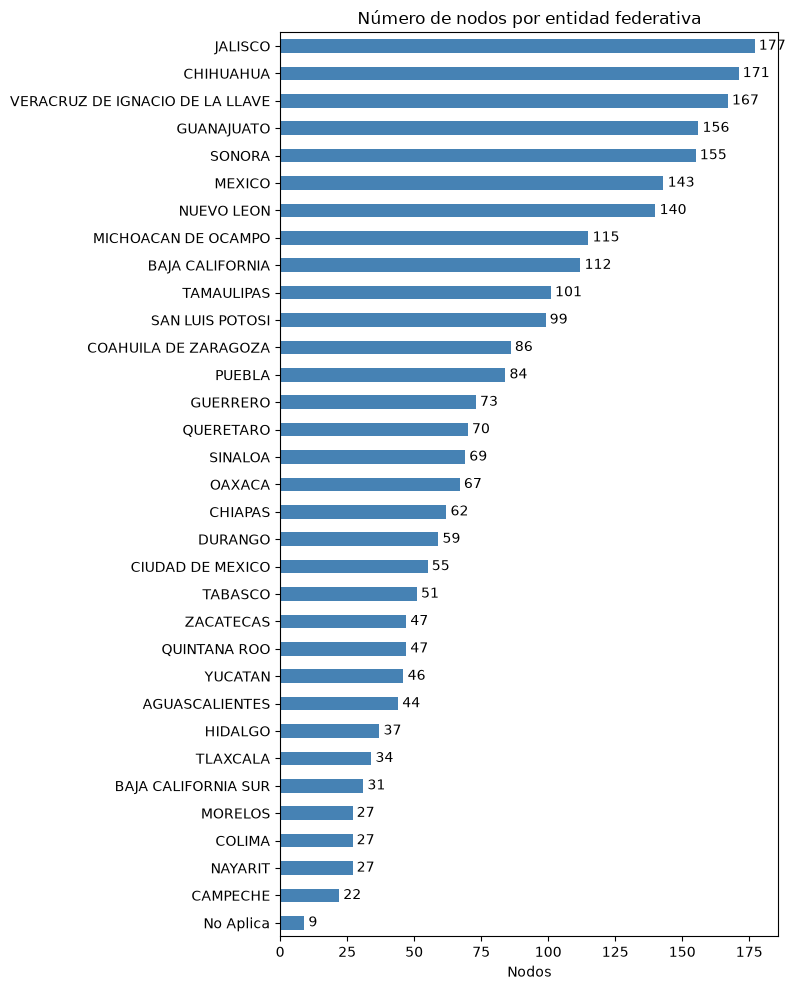

In [9]:
#Graficando el resultado:

conteo = df['ENTIDAD FEDERATIVA (INEGI)'].value_counts()

ax = conteo.sort_values().plot(kind='barh', figsize=(8, 10), color='steelblue')
ax.set_title('Número de nodos por entidad federativa')
ax.set_xlabel('Nodos')
ax.set_ylabel('')
ax.bar_label(ax.containers[0], padding=3) 
plt.tight_layout()
plt.show()

### Observando los datos para el resultado 'No Aplica'

In [10]:
#Observando los datos para el resultado 'No Aplica'
df_na = df[(df['ENTIDAD FEDERATIVA (INEGI)'] == 'No Aplica')]
print('La cantidad de nodos en "No aplica" es de:', len(df_na))
df_na[['SISTEMA', 'CLAVE', 'NOMBRE', 'NIVEL DE TENSIÓN (kV)']]

#df_na.columns.tolist()


La cantidad de nodos en "No aplica" es de: 9


,SISTEMA,CLAVE,NOMBRE,NIVEL DE TENSIÓN (kV)
528,BCA,07IVY-230,Imperial Valley,230.0
529,BCA,07OMS-230,Otay Mesa,230.0
535,SIN,09LBR-230,Los Brillantes,230.0
536,SIN,06EAP-138,Eagle Pass,138.0
537,SIN,06LAA-138,Laredo Americano,138.0
538,SIN,06RRD-138,Rail Road,138.0
539,SIN,08BEL-115,Belice,115.0
2244,SIN,05ASC-115,Ascarate,115.0
2245,SIN,05DIA-115,Diablo,115.0


Del total de nodos del catálogo, nueve se clasifican como **"No Aplica"** en el campo de entidad federativa. Esta clasificación es consistente con que se trata de puntos de interconexión ubicados en la frontera o fuera del territorio nacional, por lo que no pertenecen a ningún estado ni municipio mexicano. Estos nodos representan los enlaces del Sistema Eléctrico Nacional con las redes de los países vecinos.

### Definiendo la cantidad de nodos existentes por nivel de voltaje: 

In [11]:
df['NIVEL DE TENSIÓN (kV)'].value_counts()

NIVEL DE TENSIÓN (kV)
115.0    1944
230.0     258
69.0      158
85.0      108
138.0      62
400.0      54
161.0      23
34.5        3
Name: count, dtype: int64

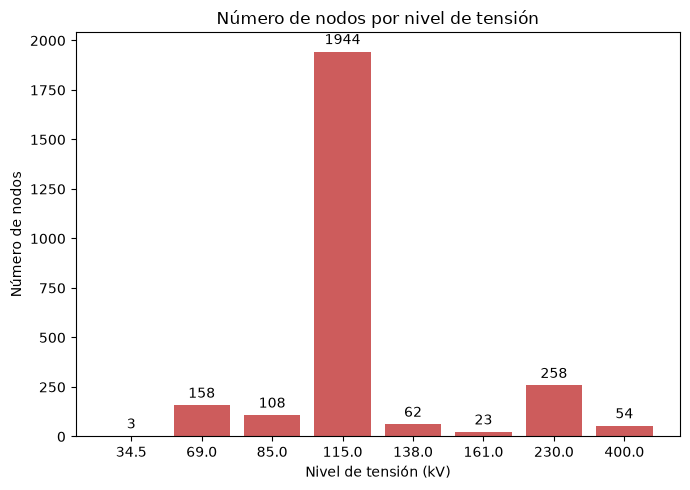

In [12]:
conteo = df['NIVEL DE TENSIÓN (kV)'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(conteo.index.astype(str), conteo.values, color='indianred')
ax.bar_label(ax.containers[0], padding=3)
ax.set_title('Número de nodos por nivel de tensión')
ax.set_xlabel('Nivel de tensión (kV)')
ax.set_ylabel('Número de nodos')
plt.tight_layout()
plt.show()

Se observa que el nivel de tensión más frecuente en los nodos del país es de **115 kV** y los menos frecuentes son de **34.5 kV** y **161.0 kV**.


Definiendo lista de las entidades del país

In [13]:
#para niveles de tension
conteo_ten = df['NIVEL DE TENSIÓN (kV)'].value_counts()
categorias_ten = conteo_ten.index.tolist()
print(categorias_ten[0])


#para estados
conteo_est = df['ENTIDAD FEDERATIVA (INEGI)'].value_counts()
estados = conteo_est.index.tolist()
print(estados)



115.0
['JALISCO', 'CHIHUAHUA', 'VERACRUZ DE IGNACIO DE LA LLAVE', 'GUANAJUATO', 'SONORA', 'MEXICO', 'NUEVO LEON', 'MICHOACAN DE OCAMPO', 'BAJA CALIFORNIA', 'TAMAULIPAS', 'SAN LUIS POTOSI', 'COAHUILA DE ZARAGOZA', 'PUEBLA', 'GUERRERO', 'QUERETARO', 'SINALOA', 'OAXACA', 'CHIAPAS', 'DURANGO', 'CIUDAD DE MEXICO', 'TABASCO', 'ZACATECAS', 'QUINTANA ROO', 'YUCATAN', 'AGUASCALIENTES', 'HIDALGO', 'TLAXCALA', 'BAJA CALIFORNIA SUR', 'COLIMA', 'NAYARIT', 'MORELOS', 'CAMPECHE', 'No Aplica']


### Imprimiendo numero de nodos por estado y nivel de tension:

In [14]:
resultados = []
for estado in estados:
    for tension in categorias_ten:
        n = ((df['ENTIDAD FEDERATIVA (INEGI)'] == estado) &
             (df['NIVEL DE TENSIÓN (kV)'] == tension)).sum()   # suma de booleanos = conteo
        resultados.append({'Entidad': estado, 'Tensión (kV)': tension, 'Nodos': n})

res = pd.DataFrame(resultados) 

tabla = res.pivot(index='Entidad', columns='Tensión (kV)', values='Nodos')
tabla['Total'] = tabla.sum(axis=1)
tabla = tabla.sort_values('Total', ascending=False)
tabla

Tensión (kV),34.5,69.0,85.0,115.0,138.0,161.0,230.0,400.0,Total
Entidad,,,,,,,,,
JALISCO,0,86,0,74,0,1,13,3,177
CHIHUAHUA,0,0,0,160,0,0,11,0,171
VERACRUZ DE IGNACIO DE LA LLAVE,0,5,0,154,0,0,3,5,167
GUANAJUATO,0,0,0,147,0,0,8,1,156
SONORA,0,0,0,131,0,1,21,2,155
MEXICO,0,0,60,38,0,0,44,1,143
NUEVO LEON,0,0,0,124,0,0,8,8,140
MICHOACAN DE OCAMPO,0,13,1,94,0,1,4,2,115
BAJA CALIFORNIA,0,44,0,27,0,20,21,0,112
